In [1]:
# импортируем необходимые для работы библиотеки
import numpy as np
import pandas as pd
import scipy as sc
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.stats.multicomp as mc
import scipy.stats as st
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy.stats import mannwhitneyu
from scipy.stats import kstest
import warnings
# убираем незначительные предупреждения
warnings.filterwarnings('ignore')

In [2]:
# ГЕНЕРАТОРЫ ВЫБОРОК
# генератор выборки для нормального распределения
def generate_random_normal(sample_size, mean, std):
    """
    Генерирует нормально распределенную случайную выборку.
    Принимает параметры:
    - sample_size: int
        Размер выборки.
    - mean: int
        Среднее выборки.
    - std: int
        Стандартное отклонение выборки.
    Возвращает параметры: нормально распределенная выборка.
    Задано ограничение: отсутствует.
    """
    return [np.random.normal(loc=mean, scale=std) for _ in range(sample_size)]

# генератор выборки для случайного распределения
def generate_random(sample_size, max_value):
    """
    Генерирует случайную выборку.
    Принимает параметры:
    - sample_size: int
        Размер выборки.
    - max_value: int
        Максимальное значение.
    Возвращает параметры: случайно распределенная выборка.
    Задано ограничение: отсутствует.
    """
    return [np.random.randint(max_value) for _ in range(sample_size)]

# генератор двух зависимых выборок(база + шум) на примере экспоненциально распределенных данных
def generate_dependent_samples(scale_difference, sample_size):
    """
    Генерирует пару зависимых выборок.
    Принимает параметры:
    - scale_difference: int
        Масштаб распределения.
    - sample_size: int
        Размер выборки.
    Возвращает параметры: две зависимые выборки.
    Задано ограничение: отсутствует.
    """
    before = np.random.exponential(scale=scale_difference, size=sample_size) # До
    difference = np.random.exponential(scale=scale_difference+2, size=sample_size) # Шум
    after = before + difference # После
    return before, after

# ПРОВЕРКА УСЛОВИЙ ПРИМЕНЕНИЯ ДЛЯ ПАРАМЕТРИЧЕСКИХ ТЕСТОВ
# визуальное представление - гистограмма
def hist_sample(data, title):
    """
    Отрисовывает гистограмму.
    Принимает параметры:
    - data: DataFrame
        Выборка.
    - title: string
        Название выборки.
    Задано ограничение по количеству столбцов: n = 30.
    """
    plt.hist(data, bins=30)
    plt.title(title)
    plt.xlabel('Значения')
    plt.ylabel('Частота')
    plt.show()

# визуальное представление - Q-Q plot
def qq_plot_sample(data, title):
    """
    Отрисовывает Q-Q plot.
    Принимает параметры:
    - data: DataFrame
        Выборка.
    - title: string
        Название выборки.
    Задано ограничение по линии: 'q'(тип контрольной линии, проходит через 1й и 3й квартили, показывает совпадение с теоретическим распределением).
    """
    sm.qqplot(data, line='q')
    plt.title(title)
    plt.show()

# проверка характера распределения критерием Шапиро-Уилка
def shapiro_uilk(title, sample, alpha):
    """
    Критерий Шапиро-Уилка подтверждает или опровергает нормальность распределения.
    Принимает параметры:
    - title: string
        Название выборки.
    - sample: DataFrame
        Выборка.
    - alpha: float
        P-значение для заданной гипотезы.
    Возвращает параметры:
    - stat: float
        Статистика теста.
    - p: float
        P-значение рассчитанное для заданной гипотезы.
    Ограничения по размеру выборки: возможны искажения в выборках при n < 3 и n > 5000.
    """
    stat, p = st.shapiro(sample)
    if p < alpha:
        print(f'Статистика по выборке {title} - {stat}. P-value - {p}. Отклонить гипотезу о нормальности распределения.')
    else:
        print(f'Статистика по выборке {title} - {stat}. P-value - {p}. Принять гипотезу о нормальности распределения.')
    return stat, p

# расчет показателей выборки
def sample_stats(sample):
    """
    Производит расчет следующих показателей выборки: стандартное отклонение, стандартная ошибка, среднее, медиана, дисперсия.
    Принимает параметры:
    - sample: DataFrame
        Выборка.
    Возвращает параметры:
    - std_dev: float
        Стандартное отклонение.
    - std_err: float
        Стандартная ошибка.
    - mean: float
        Выборочное среднее.
    - median: float
        Медиана.
    - var: float
        Дисперсия.
    Ограничения по размеру выборки: явных ограничений нет.
    """
    std_dev = np.std(sample, ddof=1) # число степеней свободы, оценка стандартного отклонения генеральной совокупности при работе с выборкой данных, а не со всей генеральной совокупностью
    std_err = std_dev / np.sqrt(len(sample))
    mean = np.mean(sample)
    median = np.median(sample)
    var = np.var(sample, ddof=1) # число степеней свободы, оценка стандартного отклонения генеральной совокупности при работе с выборкой данных, а не со всей генеральной совокупностью
    return std_dev, std_err, mean, median, var

# проверка дисперсии на гомогенность - тест Левена
def test_leven(*samples, alpha):
    """
    Тест Левена подтверждает или опровергает гипотезу о гомогенности(схожесть) дисперсии выборок.
    Принимает параметры:
    - *samples: DataFrame
        Выборки.
    - alpha: float
        P-значение для заданной гипотезы.
    Возвращает параметры:
    - stat: float
        Статистика теста.
    - p: float
        P-значение рассчитанное для заданной гипотезы.
    Ограничения по размеру выборки: n >= 2.
    """
    stat, p = st.levene(*[np.asarray(s).flatten() for s in samples]) # DataFrame сворачивается в одномерный массив
    if p < alpha:
        print(f'Статистика Левена по выборкам - {stat}. P-value - {p}. Отвергаем гипотезу о гомогенности дисперсий выборок.')
    else:
        print(f'Статистика Левена по выборкам - {stat}. P-value - {p}. Принимаем гипотезу о гомогенности дисперсий выборок.')
    return stat, p

# ПАРАМЕТРИЧЕСКИЕ ТЕСТЫ
# T-ТЕСТЫ СТЬЮДЕНТА
# t-тест Стьюдента одновыборочный
def student_test_one_sample(sample, sample_mean, test_type, alpha):
    """
    Выполняет одновыборочный t-тест Стьюдента.
    Принимает параметры:
    - sample: DataFrame
        Выборка.
    - sample_mean: float, int
        Предполагаемое среднее, с которым сверяется выборочное среднее.
    - test_type: string
        Выбор типа теста: 
            1. 'two-sided' - двусторонний тест(интересует любое отклонение),
            2. 'less' - левосторонний тест(предполагается, что среднее выборки меньше заданного среднего),
            3. 'greater' - правосторонний тест(предполагается, что среднее выборки больше заданного среднего).
    - alpha: float
        P-значение для заданной гипотезы.
    Возвращает параметры:
    - stat: float
        Статистика теста.
    - p: float
        P-значение рассчитанное для заданной гипотезы.
    Ограничения по размеру выборки: n > 5.
    """
    stat, p = st.ttest_1samp(sample.values.flatten(), sample_mean, alternative=test_type)
    if p < alpha:
        print(f'Статистика Стьюдента по выборке и среднему - {stat}. P-value - {p}. Отвергаем нулевую гипотезу: среднее значение выборки отличается от предполагаемого среднего.')
    else:
        print(f'Статистика Стьюдента по выборке и среднему - {stat}. P-value - {p}. Не отвергаем нулевую гипотезу: нет оснований утверждать, что среднее выборки отличается от предполагаемого среднего.')
    return stat, p

# t-тест Стьюдента двухвыборочный
def student_test_two_samples(sample_1, sample_2, test_type, equal_var, alpha):
    """
    Выполняет двухвыборочный t-тест Стьюдента.
    Принимает параметры:
    - sample_1, sample_2: DataFrame
        Выборки, которые сравниваются друг с другом.
    - test_type: string
        Выбор типа теста:
            1. 'two-sided' - двусторонний тест(интересует любое отклонение),
            2. 'less' - левосторонний тест(предполагается, что среднее выборки №1 меньше среднего выборки №2),
            3. 'greater' - правосторонний тест(предполагается, что среднее выборки №1 больше среднего выборки №2).
    - equal_var: bool
        - если True - предполагается равенство дисперсий,
        - если False - дисперсии не равны/не гомогенны(тест Уэлча).
    - alpha: float
        P-значение для заданной гипотезы.
    Возвращает параметры:
    - stat: float
        Статистика теста.
    - p: float
        P-значение рассчитанное для заданной гипотезы.
    Ограничения по размеру выборки: n > 5.
    """
    stat, p = st.ttest_ind(sample_1.values.flatten(), sample_2.values.flatten(), alternative=test_type, equal_var=equal_var)
    if p < alpha:
        print(f'Статистика Стьюдента по выборкам - {stat}. P-value - {p}. Отвергаем нулевую гипотезу о равенстве средних.')
    else:
        print(f'Статистика Стьюдента по выборкам - {stat}. P-value - {p}. Не отвергаем нулевую гипотезу о равенстве средних.')
    return stat, p

# ТЕСТЫ ANOVA
# однофакторный тест ANOVA
def anova_one(*samples, alpha):
    """
    Выполняет однофакторный дисперсионный анализ выборок: ANOVA не сравнивает средние напрямую, а использует соотношение 
    межгрупповой и внутригрупповой дисперсии, чтобы определить, являются ли наблюдаемые различия между средними значениями
    статистически значимыми или случайными.
    Принимает параметры:
    - *samples: DataFrame
        Выборки, которые сравниваются друг с другом.
    - alpha: float
        P-значение для заданной гипотезы.
    Возвращает параметры:
    - f_stat: float
        F-статистика теста.
    - p: float
        P-значение рассчитанное для заданной гипотезы.
    Ограничения по количеству выборок: n > 2.
    """
    flatten_samples = [sample.values.flatten() for sample in samples]    
    f_stat, p = st.f_oneway(*flatten_samples)
    if p < alpha:
        print(f'F-критерий ANOVA по группам выборок - {f_stat}. P-value - {p}. Отвергаем нулевую гипотезу о равенстве средних.')
    else:
        print(f'F-критерий ANOVA по группам выборок - {f_stat}. P-value - {p}. Не отвергаем нулевую гипотезу о равенстве средних.')
    return f_stat, p

# постанализ для параметрического теста ANOVA - проведение теста Тьюки HSD
def post_analysis_anova_tukey(*samples, alpha):
    """
    Выполняет попарное сравнение средних значений нескольких групп после получения значимого результата ANOVA(p < 0.05).
    Принимает параметры:
    - *samples: DataFrame
        Выборки, которые сравниваются друг с другом.
    - alpha: float
        P-значение для заданной гипотезы.
    Возвращает параметры:
    - tukey_post_result: table
        Таблица попарного сравнения групп между собой с указанием разницы средних,
        p-value, доверительные интервалы для каждой пары выборок, reject-флаг,
        показывающий отвергается ли Н0 при заданном уровне alpha для заданной пары выборок.
    Ограничения по количеству групп: n > 2.
    Ограничения по количеству наблюдений: n > 3.
    """
    tukey_df = pd.DataFrame()
    for sample in samples:
        group_name = sample.columns[0]
        sample = sample.rename(columns={group_name: 'Значения'})
        sample['Группа'] = group_name
        tukey_df = pd.concat([tukey_df, sample], ignore_index=True)
    tukey_post_result = mc.pairwise_tukeyhsd(endog=tukey_df['Значения'], groups=tukey_df['Группа'], alpha=0.05)
    print(tukey_post_result.summary())
    tukey_post_result.plot_simultaneous()
    return tukey_post_result

# НЕПАРАМЕТРИЧЕСКИЕ ТЕСТЫ
# критерий Манна-Уитни для двух независимых выборок
def mann_uitni(sample_1, sample_2, test_type, alpha):
    """
    Сравнивает распределения, медианы двух независимых выборок. Непараметрический аналог t-теста Стьюдента.
    Принимает параметры:
    - *samples: DataFrame
        Выборки, которые сравниваются друг с другом.
    - test_type: string
        Выбор типа теста: 
            1. 'two-sided' - двусторонний тест(интересует любое отклонение),
            2. 'less' - левосторонний тест(проверяет, сдвинуто ли распределение выборки №1 влево относительно распределения выборки №2),
            3. 'greater' - правосторонний тест(предполагается, что распределение выборки №1 сдвинуто вправо относительно распределения выборки №2).
    - alpha: float
        P-значение для заданной гипотезы.
    Возвращает параметры:
    - u_stat: float
        U-статистика теста(показывает на сколько хорошо ранги двух выборок разделены, чем меньше, тем сильнее различия между выборками).
    - p: float
        P-значение рассчитанное для заданной гипотезы.
    Ограничения по количеству выборок: n = 2.
    Ограничения по количеству наблюдений: n > 3.
    """
    u_stat, p = mannwhitneyu(sample_1.values.flatten(), sample_2.values.flatten(), alternative=test_type)
    if p < alpha:
        print(f'U-критерий Манна-Уитни по группам выборок - {u_stat}. P-value - {p}. Отвергаем нулевую гипотезу о схожести медиан/распределений двух групп.')
    else:
        print(f'U-критерий Манна-Уитни по группам выборок - {u_stat}. P-value - {p}. Не отвергаем нулевую гипотезу о схожести медиан/распределений двух групп.')
    return u_stat, p

# критерий Вилкоксона для двух зависимых выборок
def wilcoxon(sample_1, sample_2, test_type, alpha):
    """
    Сравнивает ранги разностей парных наблюдений между двумя сериями измерений на одних и тех же объектах(сравнение до-после зависимых данных).
    Принимает параметры:
    - *samples: DataFrame
        Выборки, которые сравниваются друг с другом(sample_1 - до, sample_2 - после).
    - test_type: string
        Выбор типа теста: 
            1. 'two-sided' - двусторонний тест(проверяет нулевую гипотезу о том, что ранги разностей равны нулю),
            2. 'less' - левосторонний тест(Н0 - ранги разностей одинаковы, Н1 - ранги разностей меньше меньше нуля(когда одна выборка значительно меньше другой)),
            3. 'greater' - правосторонний тест(Н0 - ранги разностей одинаковы, Н1 - ранги разностей больше нуля(когда одна выборка значительно больше другой)).
    - alpha: float
        P-значение для заданной гипотезы.
    Возвращает параметры:
    - w_stat: float
        Статистика теста.
    - p: float
        P-значение рассчитанное для заданной гипотезы.
    Ограничения по количеству выборок: n = 2.
    Ограничения по количеству наблюдений: n > 5.
    """
    w_stat, p = st.wilcoxon(sample_1.values.flatten(), sample_2.values.flatten(), alternative=test_type)
    if p < alpha:
        print(f'Критерий Вилкоксона по группам выборок - {w_stat}. P-value - {p}. Отвергаем нулевую гипотезу о схожести рангов разностей пары.')
    else:
        print(f'Критерий Вилкоксона по группам выборок - {w_stat}. P-value - {p}. Не отвергаем нулевую гипотезу о схожести рангов разностей пары.')
    return w_stat, p

# критерий Колмогорова-Смирнова для проверки совпадения распределений для двух независимых выборок
def kolmogorov_smirnov(sample_1, sample_2, test_type, alpha):
    """
    Проверка совпадений распределений(независимые данные).
    Принимает параметры:
    - sample_1, sample_2: DataFrame
        Выборки, которые сравниваются друг с другом.
    - alpha: float
        P-значение для заданной гипотезы.
    Возвращает параметры:
    - d_stat: float
        Статистика теста(максимальное расстояние между кумулятивными функциями распределения).
    - p: float
        P-значение рассчитанное для заданной гипотезы.
    Ограничения по количеству выборок: n = 2.
    Ограничения по количеству наблюдений: n > 30.
    """
    d_stat, p = st.kstest(sample_1.values.flatten(), sample_2.values.flatten(), alternative=test_type)
    if p < alpha:
        print(f'Критерий Колмогорова-Смирнова по группам выборок - {d_stat}. P-value - {p}. Отвергаем нулевую гипотезу. Выборки, вероятно, имеют разные распределения.')
    else:
        print(f'Критерий Колмогорова-Смирнова по группам выборок - {d_stat}. P-value - {p}. Не отвергаем нулевую гипотезу. Выборки, вероятно, имеют одинаковое распределение.')
    return d_stat, p

# ПАЙПЛАЙНЫ ПО ТЕСТАМ
# пайплайн для параметрических тестов
def pipeline_all_params(samples, 
                        names, 
                        indicator, 
                        alpha=0.05, 
                        type_test='',
                        subtype_test='',
                        equal_var=True):
    """
    Сценарии пайплайна параметрических тестов
    Принимает параметры:
    - samples: DataFrame array
        Выборки, которые анализируются в рамках параметрических тестов.
    - names: string array
        Названия выборок, которые анализируются в рамках параметрических тестов.
    - indicator: float, int
        Предполагаемое среднее, с которым сверяется выборочное среднее(если необходимо для выбранного типа теста).
    - alpha: float
        P-значение для заданной гипотезы.
    - type_test: string
        Тип проводимого теста: student_one_sample, student_two_samples, anova_one, anova_two
    - subtype_test: string
        Выбор типа теста: 
            1. 'two-sided' - двусторонний тест(интересует любое отклонение),
            2. 'less' - левосторонний тест(предполагается, что среднее выборки меньше заданного среднего),
            3. 'greater' - правосторонний тест(предполагается, что среднее выборки больше заданного среднего).
    - equal_var: bool
        - если True - предполагается равенство дисперсий,
        - если False - дисперсии не равны/не гомогенны(тест Уэлча).
    Возвращает параметры: данные статистик и резюме по проверяемой гипотезе.
    """
    print(f'Анализ выборок: {", ".join(names)}')
    # строим гистограммы и QQ plot для визуальной оценки распределений и проверяем характер распределений для каждой выборки критерием Шапиро-Уилка
    shapiro_p = []
    for sample, name in zip(samples, names):
        hist_sample(sample.values.flatten(), (f'Гистограмма для выборки {name}'))
        qq_plot_sample(sample.values.flatten(), (f'QQ-plot для выборки - {name}'))
        # выводим показатели выборок
        stats_labels = [
            'Стандартное отклонение (σ)',
            'Стандартная ошибка (SE)',
            'Среднее значение (μ)',
            'Медиана',
            'Дисперсия (σ²)'
        ]
        print(f'Стат показатели выборки {name}:')
        for label, value in zip(stats_labels, sample_stats(sample)):
            print(f'{label}: {float(value)}')
        print('-------------------------------------------------')
        # проверяем характер распределения критерием Шапиро-Уилка
        print(f'Критерий Шапиро-Уилка по выборке {name}:')
        stat, p = shapiro_uilk(name, sample, alpha)
        shapiro_p.append(p)
    print('-------------------------------------------------')
    # если по одной из выборок распределение не является нормальным -> рекомендуется использовать непараметрические тесты
    if all(i >= alpha for i in shapiro_p):
        # выбираем параметрический тест в зависимости от выбранного типа теста
        if type_test == 'student_one_sample':
            # проверяем итоговые статистики одновыборочного t-теста Стьюдента
            print(f'Одновыборочный тест Стьюдента по выборке {names[0]} для определения адекватности гипотез:')
            student_test_one_sample(samples[0], indicator, subtype_test, alpha=alpha)
        if type_test == 'student_two_samples':
            # проверяем дисперсии на гомогенность тестом Левена
            print(f'Тест Левена по выборкам {", ".join(names)}:')
            stat, p = test_leven(*samples, alpha=alpha)
            print('-------------------------------------------------')
            if p > 0.05:
                # проверяем итоговые статистики двухвыборочного t-теста Стьюдента
                print(f'Двухвыборочный тест Стьюдента по выборкам {", ".join(names)} для определения адекватности гипотез:')
                student_test_two_samples(*samples, subtype_test, equal_var, alpha=alpha)
            else: 
                print('Критерий гомогенности дисперсий Левена не выполняется, рекомендуется воспользоваться непараметрическими тестами.')
        if type_test == 'anova_one':
            # проверяем дисперсии на гомогенность тестом Левена
            print(f'Тест Левена по выборкам {", ".join(names)}:')
            stat, p = test_leven(*samples, alpha=alpha)
            print('-------------------------------------------------')
            if p > 0.05:
                # проверяем итоговые статистики тестом однофакторной ANOVA
                f_stat, p = anova_one(*samples, alpha=alpha)
                print('-------------------------------------------------')
                # постанализ для параметрического теста ANOVA - проведение теста Тьюки HSD, если p < 0.05(обнаружены статистически значимые различия -> 
                # -> применяем пост тест Тьюки для детализации статистически значимых различий между входящими группами)
                if p < 0.05:
                    post_analysis_anova_tukey(*samples, alpha=alpha)
            else:
                print('Критерий гомогенности дисперсий Левена не выполняется, рекомендуется воспользоваться непараметрическими тестами.')
    else:
        print('Критерий нормальности распределений Шапиро-Уилка не выполняется, рекомендуется воспользоваться непараметрическими тестами.')

# пайплайн для непараметрических тестов
def pipeline_all_noparams(samples,
                          names,
                          indicator,
                          alpha=0.05,
                          type_test='',
                          subtype_test=''):
    """
    Сценарии пайплайна непараметрических тестов
    Принимает параметры:
    - samples: DataFrame array
        Выборки, которые анализируются в рамках непараметрических тестов.
    - names: string array
        Названия выборок, которые анализируются в рамках параметрических тестов.
    - indicator: float, int
        Предполагаемое среднее, с которым сверяется выборочное среднее(если необходимо для выбранного типа теста).
    - alpha: float
        P-значение для заданной гипотезы.
    - type_test: string
        Тип проводимого теста: mann_uitni, kolmogorov_smirnov, wilcoxon
    - subtype_test: string
        Выбор типа теста: 
            1. 'two-sided' - двусторонний тест(интересует любое отклонение),
            2. 'less' - левосторонний тест(предполагается, что среднее выборки меньше заданного среднего),
            3. 'greater' - правосторонний тест(предполагается, что среднее выборки больше заданного среднего).
    Возвращает параметры: данные статистик и резюме по проверяемой гипотезе.
    """
    print(f'Анализ выборок: {", ".join(names)}')
    # строим гистограммы и QQ plot для визуальной оценки распределений и проверяем характер распределений для каждой выборки
    shapiro_p = []
    for sample, name in zip(samples, names):
        hist_sample(sample.values.flatten(), f'Гистограмма для выборки {name}')
        qq_plot_sample(sample.values.flatten(), f'QQ-plot для выборки - {name}')
        # выводим показатели выборок
        stats_labels = [
            'Стандартное отклонение (σ)',
            'Стандартная ошибка (SE)',
            'Среднее значение (μ)',
            'Медиана',
            'Дисперсия (σ²)'
        ]
        print(f'Стат показатели выборки {name}:')
        for label, value in zip(stats_labels, sample_stats(sample)):
            print(f'{label}: {float(value)}')
        print('-------------------------------------------------')
        # проверяем характер распределения критерием Шапиро-Уилка, для непараметрических тестов распределение не должно быть нормальным,
        # в ином случае применяем параметрические тесты
        print(f'Критерий Шапиро-Уилка по выборке {name}:')
        stat, p = shapiro_uilk(name, sample, alpha)
        shapiro_p.append(p)
    print('-------------------------------------------------')
    # если по одной из выборок распределение не является нормальным -> используем непараметрические тесты
    if any(i < alpha for i in shapiro_p):
        # задействуем непараметрический тест в зависимости от выбранного типа теста
        if type_test == 'mann-uitni':
            # проверяем дисперсии на гомогенность тестом Левена, т.е. для критерия Манна-Уитни - желательно, чтобы дисперсии были гомогенны
            print(f'Тест Левена по выборкам {", ".join(names)}:')
            stat, p = test_leven(*samples, alpha=alpha)
            print('-------------------------------------------------')
            if p > 0.05:
                # проверяем итоговые статистики непараметрического теста Манна-Уитни
                print(f'Двухвыборочный тест Манна-Уитни по выборкам {", ".join(names)} для определения адекватности гипотез:')
                mann_uitni(*samples, test_type=subtype_test, alpha=alpha)
            else: 
                print('Критерий гомогенности дисперсий Левена не выполняется, рекомендуется воспользоваться другим типом теста.')
        if type_test == 'kolmogorov-smirnov':
            # проверяем итоговые статистики непараметрического теста Колмогорова-Смирнова
            print(f'Двухвыборочный тест Колмогорова-Смирнова по выборкам {", ".join(names)} для определения адекватности гипотез:')
            kolmogorov_smirnov(*samples, test_type=subtype_test, alpha=alpha)
        if type_test == 'wilcoxon':
            # проверяем итоговые статистики непараметрического теста Вилкоксона
            print(f'Двухвыборочный тест Вилкоксона по выборкам {", ".join(names)} для определения адекватности гипотез:')
            wilcoxon(*samples, test_type=subtype_test, alpha=alpha)
    else:
        print('Критерий нормальности распределений Шапиро-Уилка выполняется, рекомендуется воспользоваться параметрическими тестами.')

Т-тест Стьюдента одновыборочный

Анализ выборок: Выборка_1


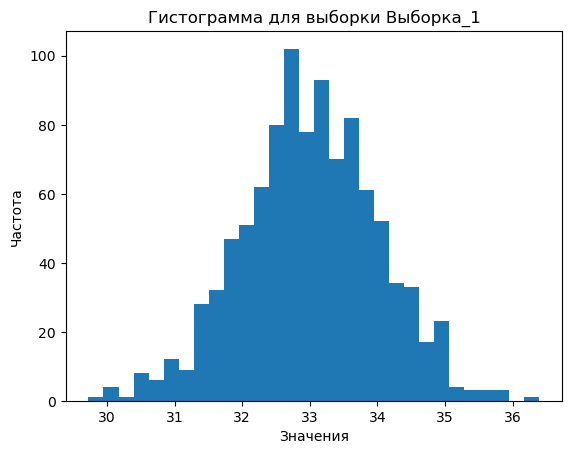

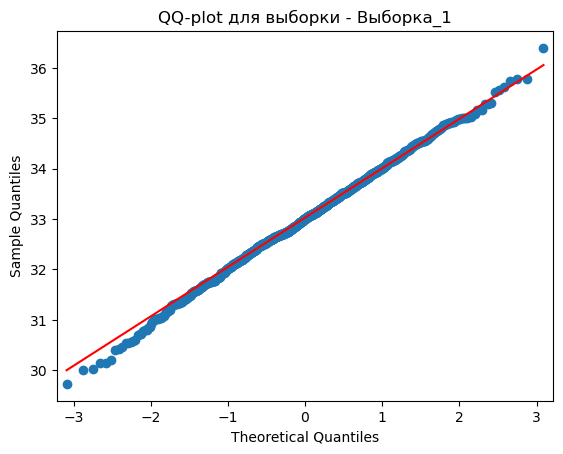

Стат показатели выборки Выборка_1:
Стандартное отклонение (σ): 1.0109531157645641
Стандартная ошибка (SE): 0.03196914453459899
Среднее значение (μ): 33.00214120627675
Медиана: 33.00504116094945
Дисперсия (σ²): 1.0220262022740803
-------------------------------------------------
Критерий Шапиро-Уилка по выборке Выборка_1:
Статистика по выборке Выборка_1 - 0.9988075494766235. P-value - 0.7597732543945312. Принять гипотезу о нормальности распределения.
-------------------------------------------------
Одновыборочный тест Стьюдента по выборке Выборка_1 для определения адекватности гипотез:
Статистика Стьюдента по выборке и среднему - -312.7346364524379. P-value - 0.0. Отвергаем нулевую гипотезу: среднее значение выборки отличается от предполагаемого среднего.


In [3]:
# сгенерируем 1 тестовую выборку и среднее для одновыборочного t-теста Стьюдента
sample_1 = pd.DataFrame(data=generate_random_normal(1000, 33, 1), columns=['Выборка_1'])
test_mean = 43
# запуск итогового "пайплайна" - функции
pipeline_all_params([sample_1], ['Выборка_1'], indicator=test_mean, alpha=0.05, type_test='student_one_sample', subtype_test='two-sided', equal_var=None)

T-тест Стьюдента двухфакторныйвыборочный

Анализ выборок: Выборка_2, Выборка_3


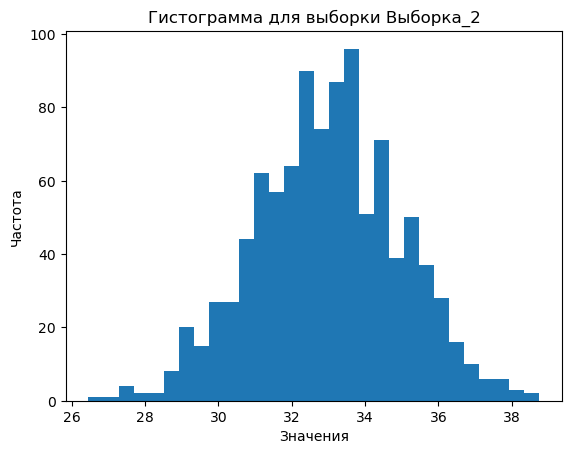

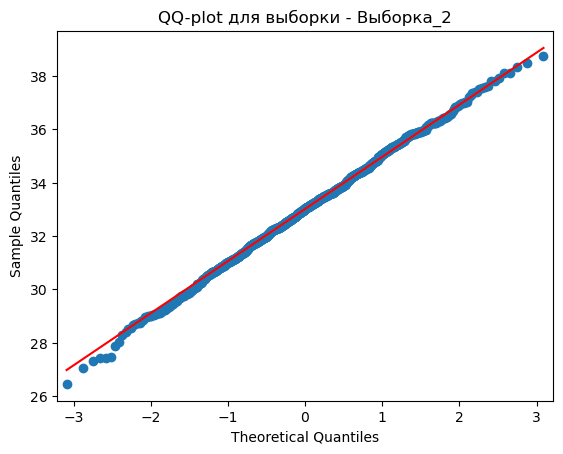

Стат показатели выборки Выборка_2:
Стандартное отклонение (σ): 1.9854329558138804
Стандартная ошибка (SE): 0.06278490281932307
Среднее значение (μ): 32.98194238008084
Медиана: 33.029698403066966
Дисперсия (σ²): 3.9419440220318416
-------------------------------------------------
Критерий Шапиро-Уилка по выборке Выборка_2:
Статистика по выборке Выборка_2 - 0.9988354444503784. P-value - 0.7776256203651428. Принять гипотезу о нормальности распределения.


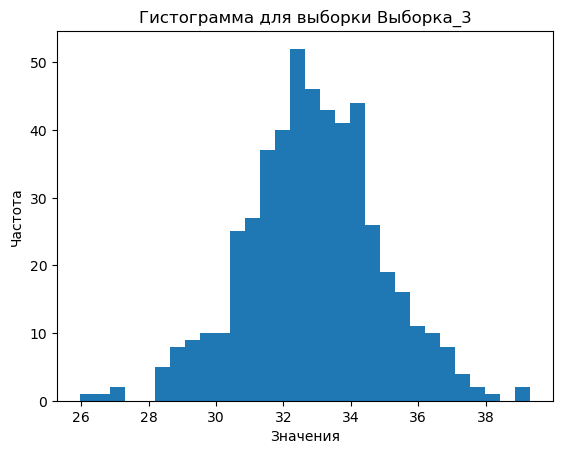

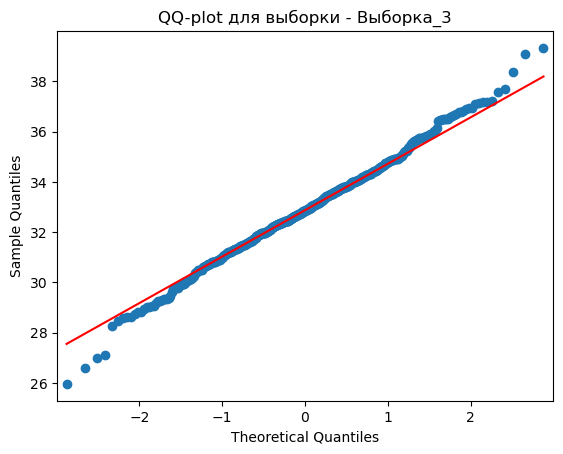

Стат показатели выборки Выборка_3:
Стандартное отклонение (σ): 1.9915003518462726
Стандартная ошибка (SE): 0.08906260327886029
Среднее значение (μ): 32.88746913613351
Медиана: 32.85730224614319
Дисперсия (σ²): 3.966073651403828
-------------------------------------------------
Критерий Шапиро-Уилка по выборке Выборка_3:
Статистика по выборке Выборка_3 - 0.9963151812553406. P-value - 0.3028527498245239. Принять гипотезу о нормальности распределения.
-------------------------------------------------
Тест Левена по выборкам Выборка_2, Выборка_3:
Статистика Левена по выборкам - 0.18183356656770042. P-value - 0.6698634828978076. Принимаем гипотезу о гомогенности дисперсий выборок.
-------------------------------------------------
Двухвыборочный тест Стьюдента по выборкам Выборка_2, Выборка_3 для определения адекватности гипотез:
Статистика Стьюдента по выборкам - 0.8678619542817069. P-value - 0.3856089135285805. Не отвергаем нулевую гипотезу о равенстве средних.


In [4]:
# сгенерируем 2 тестовые выборки для двухвыборочного t-теста Стьюдента
sample_2 = pd.DataFrame(data=generate_random_normal(1000, 33, 2), columns=['Выборка_2'])
sample_3 = pd.DataFrame(data=generate_random_normal(500, 33, 2), columns=['Выборка_3'])
# запуск итогового "пайплайна" - функции
pipeline_all_params([sample_2, sample_3], ['Выборка_2', 'Выборка_3'], indicator=None, alpha=0.05, type_test='student_two_samples', subtype_test='two-sided', equal_var=True)

Однофакторный тест ANOVA со сходными средними

Анализ выборок: Выборка_4, Выборка_5, Выборка_6


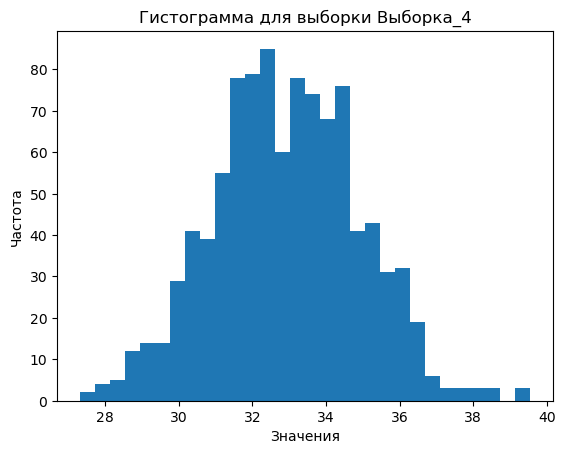

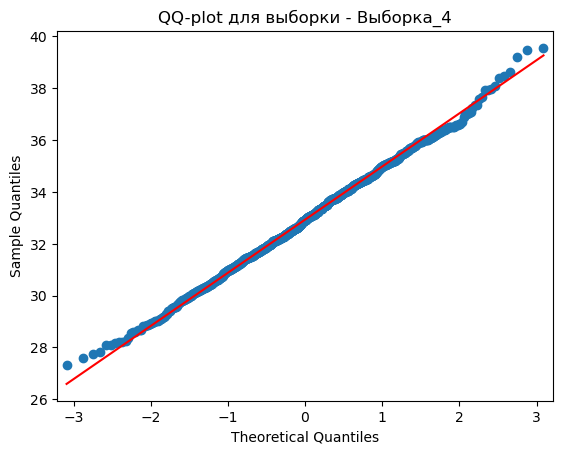

Стат показатели выборки Выборка_4:
Стандартное отклонение (σ): 1.9897546167059448
Стандартная ошибка (SE): 0.06292156573626105
Среднее значение (μ): 32.921684044903124
Медиана: 32.92656260755449
Дисперсия (σ²): 3.9591234347026214
-------------------------------------------------
Критерий Шапиро-Уилка по выборке Выборка_4:
Статистика по выборке Выборка_4 - 0.9982180595397949. P-value - 0.38622531294822693. Принять гипотезу о нормальности распределения.


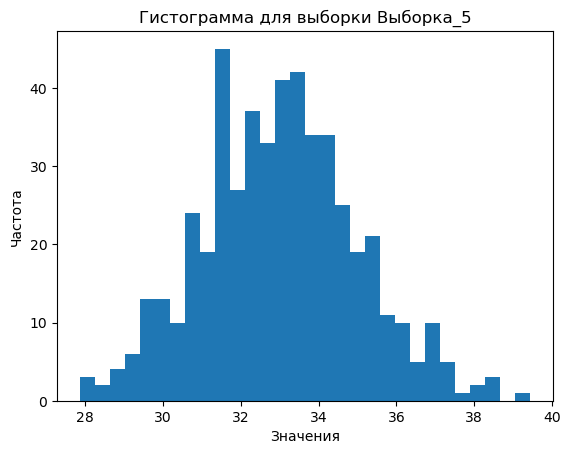

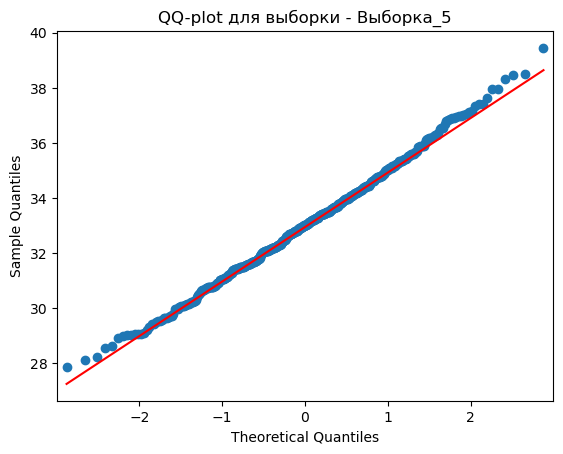

Стат показатели выборки Выборка_5:
Стандартное отклонение (σ): 1.9920924844657062
Стандартная ошибка (SE): 0.08908908425463526
Среднее значение (μ): 33.02051332969338
Медиана: 33.01882327619796
Дисперсия (σ²): 3.96843246666475
-------------------------------------------------
Критерий Шапиро-Уилка по выборке Выборка_5:
Статистика по выборке Выборка_5 - 0.9969648122787476. P-value - 0.48007115721702576. Принять гипотезу о нормальности распределения.


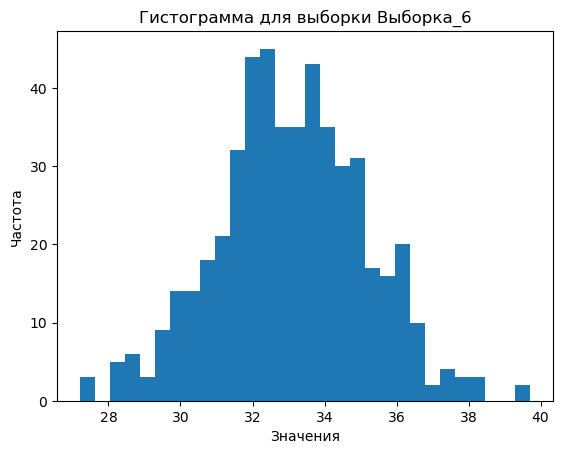

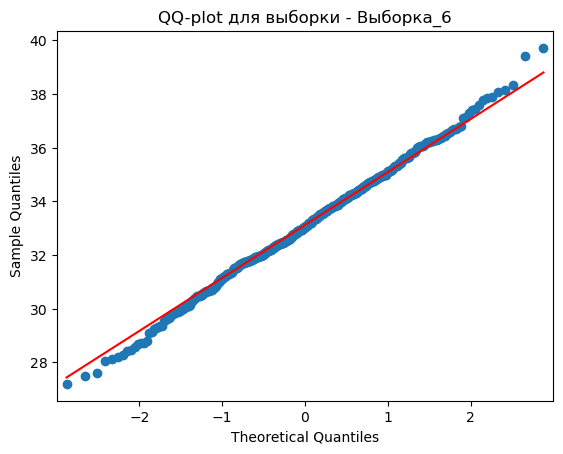

Стат показатели выборки Выборка_6:
Стандартное отклонение (σ): 2.062697257933411
Стандартная ошибка (SE): 0.09224662571483049
Среднее значение (μ): 33.09307033464241
Медиана: 33.05234275971722
Дисперсия (σ²): 4.254719977886013
-------------------------------------------------
Критерий Шапиро-Уилка по выборке Выборка_6:
Статистика по выборке Выборка_6 - 0.9981768131256104. P-value - 0.8800502419471741. Принять гипотезу о нормальности распределения.
-------------------------------------------------
Тест Левена по выборкам Выборка_4, Выборка_5, Выборка_6:
Статистика Левена по выборкам - 0.29201252766976965. P-value - 0.7467910616260321. Принимаем гипотезу о гомогенности дисперсий выборок.
-------------------------------------------------
F-критерий ANOVA по группам выборок - 1.2939752510548963. P-value - 0.2744084659330702. Не отвергаем нулевую гипотезу о равенстве средних.
-------------------------------------------------


In [5]:
# сгенерируем 3 тестовые выборки для однофакторного теста ANOVA
sample_4 = pd.DataFrame(data=generate_random_normal(1000, 33, 2), columns=['Выборка_4'])
sample_5 = pd.DataFrame(data=generate_random_normal(500, 33, 2), columns=['Выборка_5'])
sample_6 = pd.DataFrame(data=generate_random_normal(500, 33, 2), columns=['Выборка_6'])
# запуск итогового "пайплайна" - функции
pipeline_all_params([sample_4, sample_5, sample_6], ['Выборка_4', 'Выборка_5', 'Выборка_6'], indicator=None, alpha=0.05, type_test='anova_one', subtype_test=None, equal_var=True)

Однофакторный тест ANOVA с отличающимися средними

Анализ выборок: Выборка_7, Выборка_8, Выборка_9


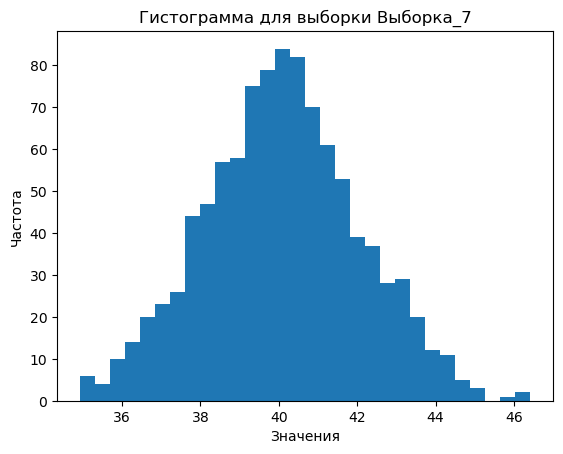

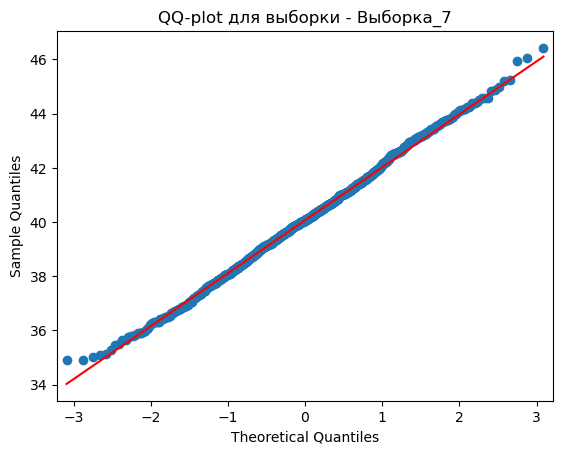

Стат показатели выборки Выборка_7:
Стандартное отклонение (σ): 1.9770396441372897
Стандартная ошибка (SE): 0.06251948299922594
Среднее значение (μ): 40.08616017439599
Медиана: 40.057074321060355
Дисперсия (σ²): 3.9086857544905014
-------------------------------------------------
Критерий Шапиро-Уилка по выборке Выборка_7:
Статистика по выборке Выборка_7 - 0.9980787038803101. P-value - 0.31717056035995483. Принять гипотезу о нормальности распределения.


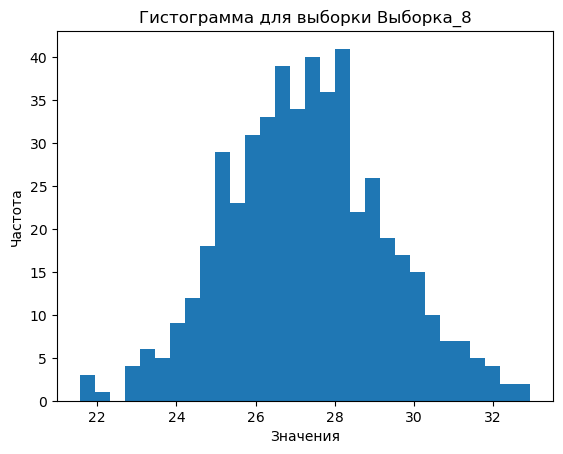

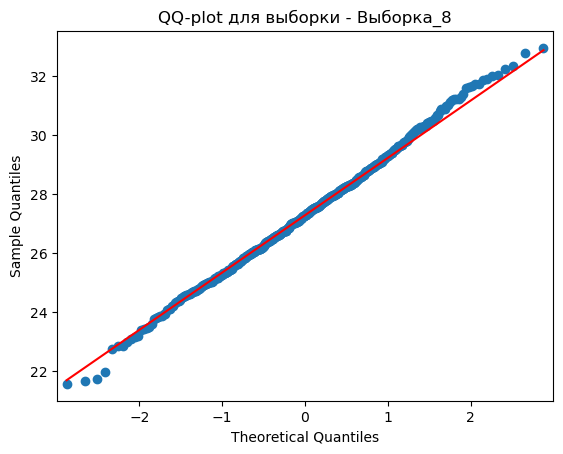

Стат показатели выборки Выборка_8:
Стандартное отклонение (σ): 2.0124269580482377
Стандартная ошибка (SE): 0.08999846955897954
Среднее значение (μ): 27.297865758825065
Медиана: 27.277169530614476
Дисперсия (σ²): 4.049862261479284
-------------------------------------------------
Критерий Шапиро-Уилка по выборке Выборка_8:
Статистика по выборке Выборка_8 - 0.9976891279220581. P-value - 0.7275399565696716. Принять гипотезу о нормальности распределения.


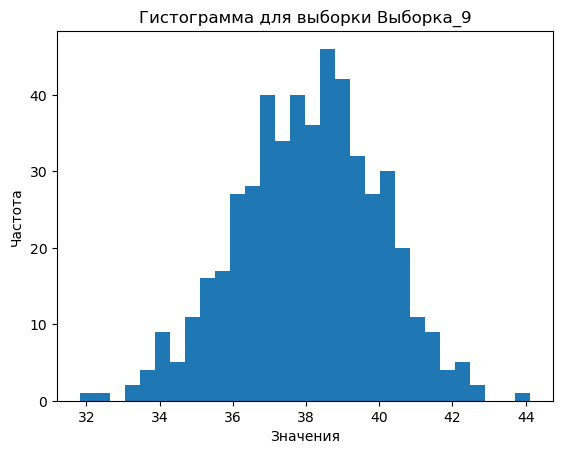

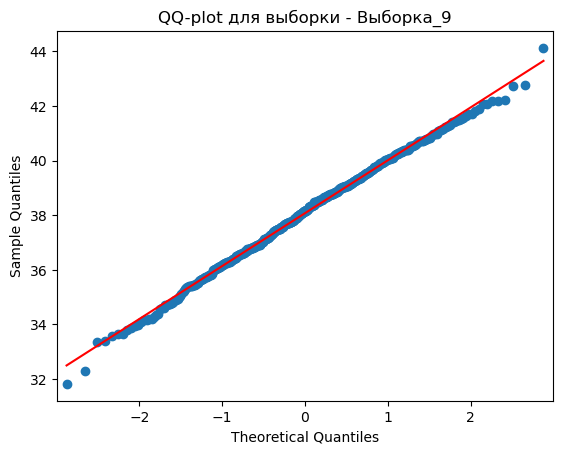

Стат показатели выборки Выборка_9:
Стандартное отклонение (σ): 1.9260924172509248
Стандартная ошибка (SE): 0.08613747151839912
Среднее значение (μ): 38.07439848780217
Медиана: 38.149598834549394
Дисперсия (σ²): 3.709831999791511
-------------------------------------------------
Критерий Шапиро-Уилка по выборке Выборка_9:
Статистика по выборке Выборка_9 - 0.9975035786628723. P-value - 0.6626622676849365. Принять гипотезу о нормальности распределения.
-------------------------------------------------
Тест Левена по выборкам Выборка_7, Выборка_8, Выборка_9:
Статистика Левена по выборкам - 0.21735502424459655. P-value - 0.8046632833757531. Принимаем гипотезу о гомогенности дисперсий выборок.
-------------------------------------------------
F-критерий ANOVA по группам выборок - 7243.150696926582. P-value - 0.0. Отвергаем нулевую гипотезу о равенстве средних.
-------------------------------------------------
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  mea

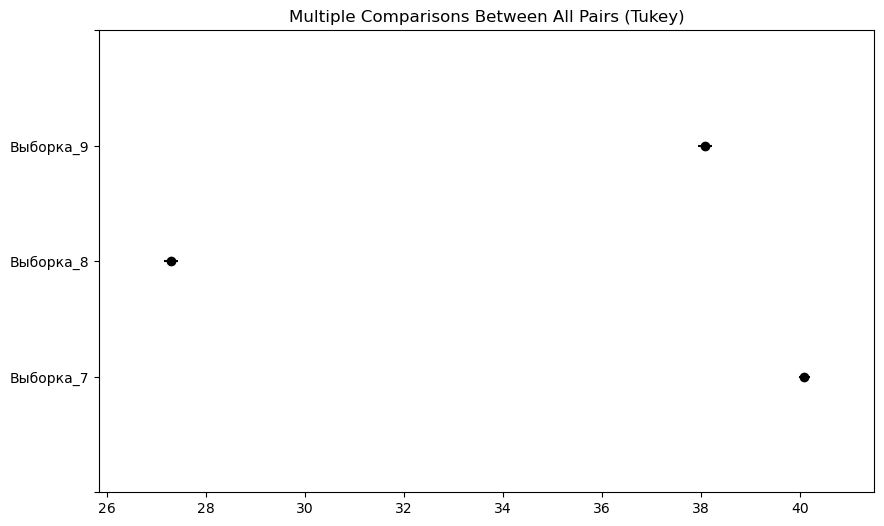

In [6]:
# сгенерируем 3 тестовые выборки для однофакторного теста ANOVA
sample_7 = pd.DataFrame(data=generate_random_normal(1000, 40, 2), columns=['Выборка_7'])
sample_8 = pd.DataFrame(data=generate_random_normal(500, 27, 2), columns=['Выборка_8'])
sample_9 = pd.DataFrame(data=generate_random_normal(500, 38, 2), columns=['Выборка_9'])
# запуск итогового "пайплайна" - функции
pipeline_all_params([sample_7, sample_8, sample_9], ['Выборка_7', 'Выборка_8', 'Выборка_9'], indicator=None, alpha=0.05, type_test='anova_one', subtype_test=None, equal_var=True)

Критерий Манна-Уитни для двух случайных независимых выборок

Анализ выборок: Выборка_10, Выборка_11


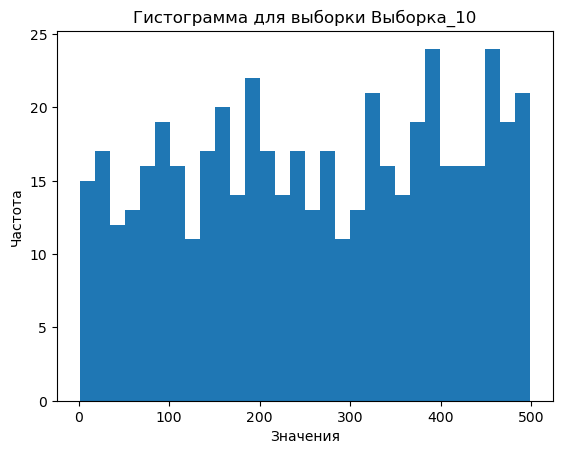

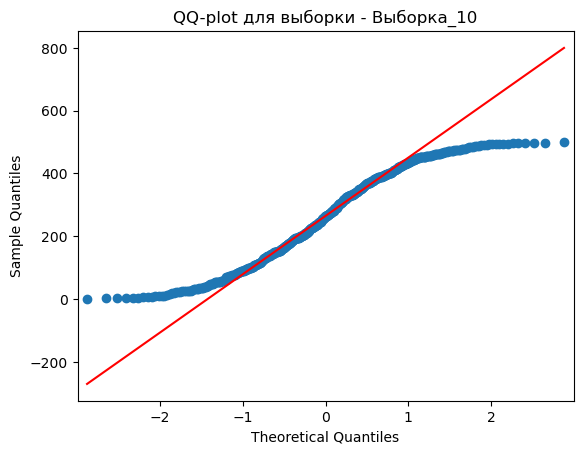

Стат показатели выборки Выборка_10:
Стандартное отклонение (σ): 145.89508046884245
Стандартная ошибка (SE): 6.524626350222672
Среднее значение (μ): 261.338
Медиана: 263.0
Дисперсия (σ²): 21285.374505010015
-------------------------------------------------
Критерий Шапиро-Уилка по выборке Выборка_10:
Статистика по выборке Выборка_10 - 0.9503443241119385. P-value - 6.51332633661017e-12. Отклонить гипотезу о нормальности распределения.


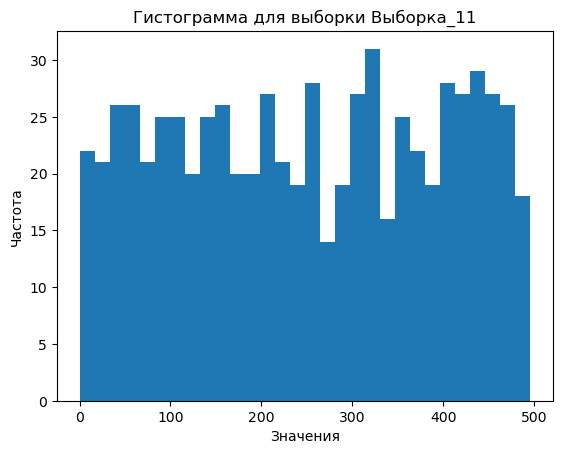

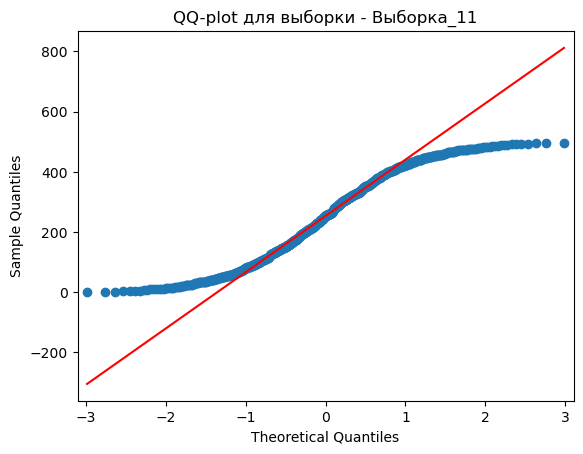

Стат показатели выборки Выборка_11:
Стандартное отклонение (σ): 144.65332296310146
Стандартная ошибка (SE): 5.467381698278219
Среднее значение (μ): 250.56428571428572
Медиана: 253.0
Дисперсия (σ²): 20924.583844267334
-------------------------------------------------
Критерий Шапиро-Уилка по выборке Выборка_11:
Статистика по выборке Выборка_11 - 0.9486072063446045. P-value - 7.0509140111816096e-15. Отклонить гипотезу о нормальности распределения.
-------------------------------------------------
Тест Левена по выборкам Выборка_10, Выборка_11:
Статистика Левена по выборкам - 0.05580026174747031. P-value - 0.8133017269931623. Принимаем гипотезу о гомогенности дисперсий выборок.
-------------------------------------------------
Двухвыборочный тест Манна-Уитни по выборкам Выборка_10, Выборка_11 для определения адекватности гипотез:
U-критерий Манна-Уитни по группам выборок - 182726.5. P-value - 0.19175861337536837. Не отвергаем нулевую гипотезу о схожести медиан/распределений двух групп.


In [7]:
# сгенерируем 2 тестовые выборки для критерия Манна-Уитни для двух случайных независимых выборок
sample_10 = pd.DataFrame(data=generate_random(500, 500), columns=['Выборка_10'])
sample_11 = pd.DataFrame(data=generate_random(700, 500), columns=['Выборка_11'])
# запустим пайплайн непараметрической функции
pipeline_all_noparams([sample_10, sample_11], ['Выборка_10', 'Выборка_11'], indicator=None, alpha=0.05, type_test='mann-uitni', subtype_test='two-sided')

Критерий Колмогорова-Смирнова для двух случайных независимых выборок

Анализ выборок: Выборка_12, Выборка_13


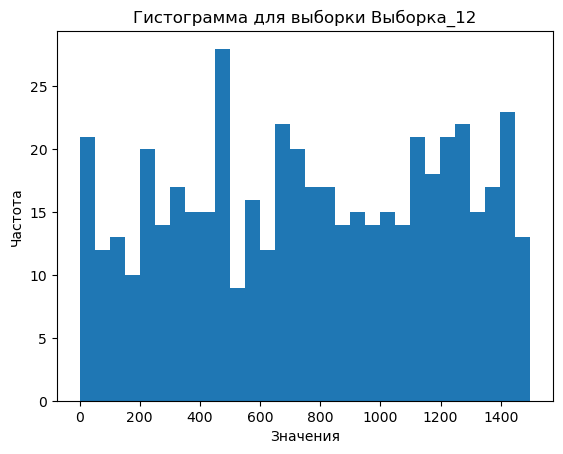

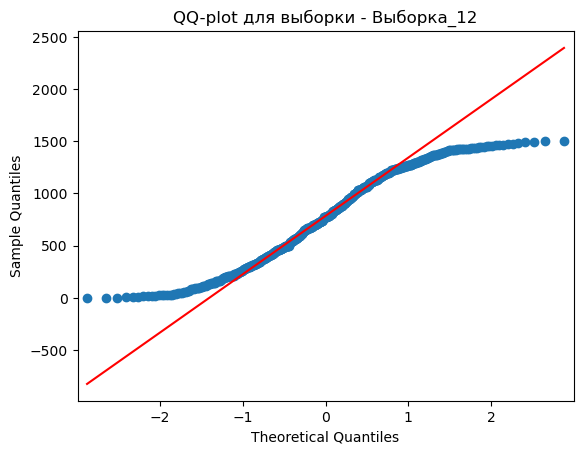

Стат показатели выборки Выборка_12:
Стандартное отклонение (σ): 432.47473961007444
Стандартная ошибка (SE): 19.340858326392947
Среднее значение (μ): 770.98
Медиана: 770.0
Дисперсия (σ²): 187034.4004008017
-------------------------------------------------
Критерий Шапиро-Уилка по выборке Выборка_12:
Статистика по выборке Выборка_12 - 0.9540352821350098. P-value - 2.310322246013019e-11. Отклонить гипотезу о нормальности распределения.


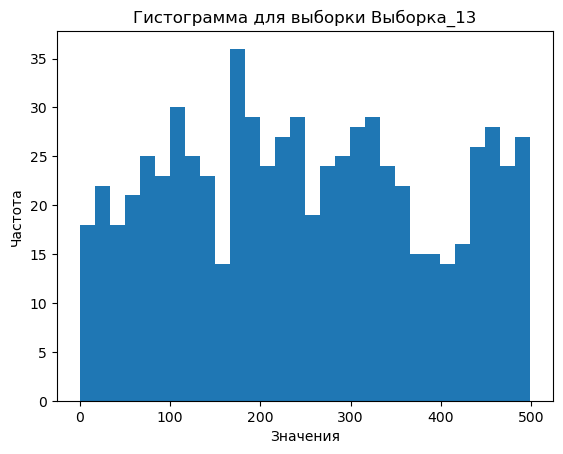

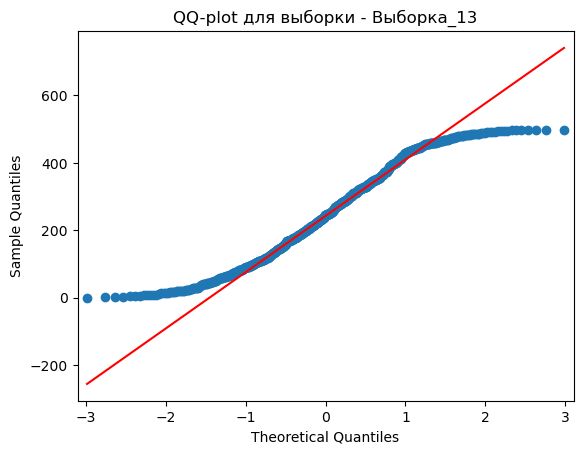

Стат показатели выборки Выборка_13:
Стандартное отклонение (σ): 140.96646885811447
Стандартная ошибка (SE): 5.328031711392888
Среднее значение (μ): 248.58285714285714
Медиана: 245.0
Дисперсия (σ²): 19871.545342325753
-------------------------------------------------
Критерий Шапиро-Уилка по выборке Выборка_13:
Статистика по выборке Выборка_13 - 0.9605159163475037. P-value - 8.797434894285139e-13. Отклонить гипотезу о нормальности распределения.
-------------------------------------------------
Двухвыборочный тест Колмогорова-Смирнова по выборкам Выборка_12, Выборка_13 для определения адекватности гипотез:
Критерий Колмогорова-Смирнова по группам выборок - 0.6711428571428572. P-value - 2.126625174346956e-125. Отвергаем нулевую гипотезу. Выборки, вероятно, имеют разные распределения.


In [8]:
# сгенерируем 2 тестовые выборки для критерия Колмогорова-Смирнова для двух случайных независимых выборок
sample_12 = pd.DataFrame(data=generate_random(500, 1500), columns=['Выборка_12'])
sample_13 = pd.DataFrame(data=generate_random(700, 500), columns=['Выборка_13'])
# запустим пайплайн непараметрической функции
pipeline_all_noparams([sample_12, sample_13], ['Выборка_12', 'Выборка_13'], indicator=None, alpha=0.05, type_test='kolmogorov-smirnov', subtype_test='two-sided')

Двухвыборочный тест Вилкоксона

Анализ выборок: До, После


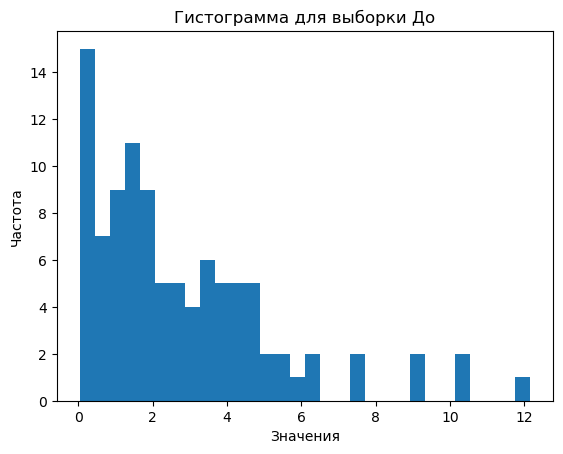

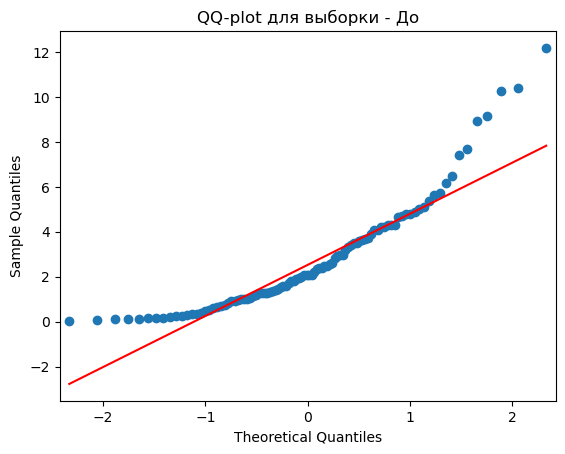

Стат показатели выборки До:
Стандартное отклонение (σ): 2.4908283570910936
Стандартная ошибка (SE): 0.24908283570910936
Среднее значение (μ): 2.7634203905478665
Медиана: 2.0539755479716146
Дисперсия (σ²): 6.204225904489117
-------------------------------------------------
Критерий Шапиро-Уилка по выборке До:
Статистика по выборке До - 0.8636466264724731. P-value - 3.918700386407181e-08. Отклонить гипотезу о нормальности распределения.


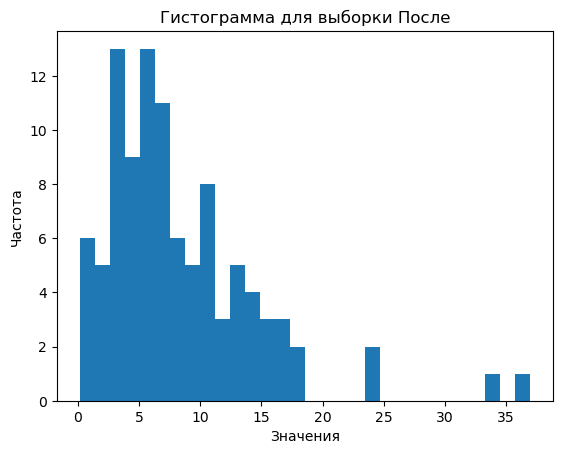

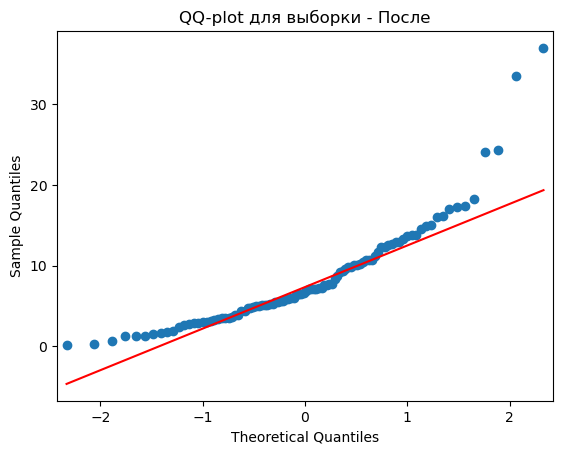

Стат показатели выборки После:
Стандартное отклонение (σ): 6.3478165064987255
Стандартная ошибка (SE): 0.6347816506498726
Среднее значение (μ): 8.299190355009998
Медиана: 6.6878080360280165
Дисперсия (σ²): 40.29477440017768
-------------------------------------------------
Критерий Шапиро-Уилка по выборке После:
Статистика по выборке После - 0.8488283157348633. P-value - 1.0736539657330013e-08. Отклонить гипотезу о нормальности распределения.
-------------------------------------------------
Двухвыборочный тест Вилкоксона по выборкам До, После для определения адекватности гипотез:
Критерий Вилкоксона по группам выборок - 0.0. P-value - 3.896559845095909e-18. Отвергаем нулевую гипотезу о схожести рангов разностей пары.


In [9]:
# генерируем две зависимые случайные выборки и проверяем работу теста Вилкоксона
before_sample, after_sample = generate_dependent_samples(3, 100)
before_sample = pd.DataFrame(data=before_sample, columns=['До'])
after_sample = pd.DataFrame(data=after_sample, columns=['После'])
# запустим пайплайн непараметрической функции
pipeline_all_noparams([before_sample, after_sample], ['До', 'После'], indicator=None, alpha=0.05, type_test='wilcoxon', subtype_test='two-sided')